# Harpy - Xenium - Introduction

In this series of notebooks, we will analyze a 10X Genomics [Xenium](https://www.10xgenomics.com/platforms/xenium) dataset using the [Harpy](https://harpy.readthedocs.io/en/latest/) package. A Python package that allows flexible, modular and scalable analysis of spatial omics datasets. The package includes tools for image processing, cell segmentation, transcript allocation and cell type annotation. We will also explore the Xenium dataset itself, introduce the SpatialData data format and how you can plot spatial data, and go over some additional analysis options, including segmentation-free approaches and downstream analysis steps.

When you make use of Harpy for analysis of spatial transcriptomics data, please cite [Pollaris et al. (2024)](https://www.biorxiv.org/content/biorxiv/early/2024/07/06/2024.07.04.601829.full.pdf) and the Harpy paper (accepted for publication in Bioinformatics).

Below, we analyze a 10,000 × 10,000 pixel subset of this dataset. For results on the complete dataset see this [link](https://harpy.readthedocs.io/en/latest/tutorials/advanced/Harpy_transcriptomics_xenium.html).

## Import packages

In [1]:
import os

import dask.array as da
import geopandas as gpd
import harpy as hp
import matplotlib.pyplot as plt
import pandas as pd
import spatialdata as sd
import spatialdata_plot

_ = spatialdata_plot  # To satisfy Ruff (otherwise Ruff would flag it as unused)

## 1. Xenium Ovarian Cancer dataset
The dataset was made publically available by 10X Genomics: [FFPE Human Ovarian Cancer with 5K Human Pan Tissue and Pathways Panel plus 100 Custom Genes](https://www.10xgenomics.com/datasets/xenium-prime-ffpe-human-ovarian-cancer). 

A single-cell RNA sequencing dataset on a consecutive section was also made available: [Human Ovarian Cancer FFPE Single Cell Gene Expression Flex (Next GEM)](https://www.10xgenomics.com/datasets/17k-human-ovarian-cancer-scFFPE). Additionally, an analysis guide from 10X Genomics on how to use this scRNA-seq reference to annotate cell types in the Xenium dataset using Seurat can be found [here](https://www.10xgenomics.com/analysis-guides/xenium-cell-type-annotation).

A good first step is to have a look at the Xenium Analysis Summary from Xenium Onboard Analysis, which can be found [here](https://cf.10xgenomics.com/samples/xenium/3.0.0/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_analysis_summary.html). Next, we can interactively explore the data using [Xenium Explorer](https://www.10xgenomics.com/support/software/xenium-explorer/latest). To do this, we need to locate the experiment.xenium file in the Xenium Onboard Analysis output folder and make sure the software is installed. In the case of this public dataset, we can also just open the [web demo](https://xenium.10xgenomics.com/?image=s3%2F10x.files%2Fxenium%2Fpreview%2FXenium_Prime_Ovarian_Cancer_FFPE_boosted%2Fexperiment.xenium&layers=cell~image~feature&cell_bt=cell&cell_c=groups&cell_g=10&cell_o=0.8&ct_c=Viridis&ct_o=0.8&ct_s=1_1276&cell_v=filled&z=14&off=&mi_v=true&axes=false&highlight=true&nav=true&rotation=0&target=32400.03_19524.55&tt_off=false&zoom=0.0179&feature=icon&feature_psc=6&feature_ps=circles&feature_off=0_188~190_220~222_349~351_421~423_765~767_806~808_1285~1287_1594~1596_2866~2868_3406~3408_4149~4151_4204~4206_4391~4393_4678~4680_4687~4689_4710~4712_4739~4741_4824~4826_4847~4849_9475&bin=10&d_c=Inferno&d_o=0.8&ii_minmax=__&ii_colors=_&ii_gamma=_&ii_b=0_0&ii_c=1_1&ii_n=H%26E%20Image%09H%26E%20Annotated%20Image&ii_o=1_1&ii_p=s3%2F10x.files%2Fxenium%2Fpreview%2FXenium_Prime_Ovarian_Cancer_FFPE_boosted%2Fhe_image.ome.tif%09s3%2F10x.files%2Fxenium%2Fpreview%2FXenium_Prime_Ovarian_Cancer_FFPE_boosted%2Fhe_annotated_image.ome.tif&ii_t=kzyedFNXhj8hKR3b5KH0P4DrlUUPiIbAISkd2%2BSh9L%2BTPJ50U1eGP8PfKbFV3uJAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAPA%2F_kzyedFNXhj8hKR3b5KH0P4DrlUUPiIbAISkd2%2BSh9L%2BTPJ50U1eGP8PfKbFV3uJAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAPA%2F&ii_v=false_false).

More information about Xenium can be found here:
- [Xenium Analyzer](https://www.10xgenomics.com/instruments/xenium-analyzer)
- [Xenium Onboard Analysis](https://www.10xgenomics.com/support/software/xenium-onboard-analysis/latest)
- [Xenium Explorer](https://www.10xgenomics.com/support/software/xenium-explorer/latest)
- [Gene panels](https://www.10xgenomics.com/products/xenium-panels#overview)
- [Xenium Prime 5K (Tech note)](https://cdn.10xgenomics.com/image/upload/v1721239182/support-documents/CG000775_Prime5K_DataHighlightsTN_RevA_updated.pdf)
- [Multimodal Cell Segmentation (Tech note)](https://cdn.10xgenomics.com/image/upload/v1754601291/support-documents/CG000750_XeniumInSitu_CellSegmentation_TechNote_RevB.pdf).

In [2]:
# Fetch the data needed for the training

from loguru import logger
from harpy.datasets.registry import get_registry

path = None  # Change path if you want to fetch the raw data in another directory than the default cache of your OS
registry = get_registry(path=path)

for _item in [
    "transcriptomics/xenium/Xenium_human_ovarian_cancer/training_march_2026/morphology_focus_0000.ome.tif",  # Fluorescent image
    "transcriptomics/xenium/Xenium_human_ovarian_cancer/training_march_2026/morphology_focus_0001.ome.tif",
    "transcriptomics/xenium/Xenium_human_ovarian_cancer/training_march_2026/morphology_focus_0002.ome.tif",
    "transcriptomics/xenium/Xenium_human_ovarian_cancer/training_march_2026/morphology_focus_0003.ome.tif",
    "transcriptomics/xenium/Xenium_human_ovarian_cancer/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_he_image.ome.tif",  # Original H&E
    "transcriptomics/xenium/Xenium_human_ovarian_cancer/training_march_2026/HE_warped_TPS.tiff",  # H&E warped by BigWarp
    "transcriptomics/xenium/Xenium_human_ovarian_cancer/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_he_imagealignment.csv",  # Alignment matrix provided by 10X
    "transcriptomics/xenium/Xenium_human_ovarian_cancer/training_march_2026/tumor.geojson",  # Region annotation from Qupath
    "transcriptomics/xenium/Xenium_human_ovarian_cancer/training_march_2026/necrosis.geojson",  # Region annotation from Qupath
    "transcriptomics/xenium/Xenium_human_ovarian_cancer/training_march_2026/ovary.geojson",  # Region annotation from Qupath
    "transcriptomics/xenium/Xenium_human_ovarian_cancer/training_march_2026/fallopian_tube.geojson",  # Region annotation from Qupath
    "transcriptomics/xenium/Xenium_human_ovarian_cancer/training_march_2026/smooth_muscle.geojson",  # Region annotation from Qupath
    # "transcriptomics/xenium/Xenium_human_ovarian_cancer/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs.zip", # Full run , not necessary to download
]:
    logger.info(f"Fetching {_item}.")
    _ = registry.fetch(_item)


_ = hp.datasets.xenium_human_ovarian_cancer(subset=True, path=path)

2026-03-10 20:12:26.036 | INFO     | __main__:<module>:24 - Fetching transcriptomics/xenium/Xenium_human_ovarian_cancer/training_march_2026/morphology_focus_0000.ome.tif.
2026-03-10 20:12:26.637 | INFO     | __main__:<module>:24 - Fetching transcriptomics/xenium/Xenium_human_ovarian_cancer/training_march_2026/morphology_focus_0001.ome.tif.
2026-03-10 20:12:27.428 | INFO     | __main__:<module>:24 - Fetching transcriptomics/xenium/Xenium_human_ovarian_cancer/training_march_2026/morphology_focus_0002.ome.tif.
2026-03-10 20:12:27.959 | INFO     | __main__:<module>:24 - Fetching transcriptomics/xenium/Xenium_human_ovarian_cancer/training_march_2026/morphology_focus_0003.ome.tif.
2026-03-10 20:12:28.699 | INFO     | __main__:<module>:24 - Fetching transcriptomics/xenium/Xenium_human_ovarian_cancer/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_he_image.ome.tif.
2026-03-10 20:12:30.650 | INFO     | __main__:<module>:24 - Fetching transcriptomics/xenium/Xenium_human_ovarian_cancer/training_march_2026

## 2. Create SpatialData
In the case of Xenium data, Harpy contains a convenient reader function that reads in the images, transcripts, segmentation masks and tables into a SpatialData object that is backed to a Zarr store. 

Note that Harpy has a similar reader function for Vizgen MERSCOPE datasets (`hp.io.merscope`) and that other imaging-based spatial transcriptomics datasets can be read using a combination of more general functions (`harpy.io.create_sdata`, `hp.io.read_transcripts`, `hp.im.add_image_layer`...). See [documentation Harpy](https://harpy.readthedocs.io/en/latest/index.html) for more details.

In [3]:
# Specify paths
output_path = "/Users/arne.defauw/VIB/DATA/test_data"  # CHANGE THIS. Set a path to save the output from Harpy


cropped_zarr_path = os.path.join(output_path, "sdata_xenium_intro.zarr")

In [4]:
# NOTE: Because the dataset is large, we will not read it in using the reader below, but we will download a cropped version from our registry.
# The code below is what we used to read in the data and crop it to the region of interest.

"""
import pooch

import harpy as hp

zarr_path = os.path.join(output_path, "sdata.zarr")

path = None # change path if you want to fetch the raw data in another directory than the default cache of your OS
registry = get_registry(path=path)
path_unzipped = registry.fetch(
    "transcriptomics/xenium/Xenium_human_ovarian_cancer/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs.zip",
    processor=pooch.Unzip(extract_dir="."),
)

input_path = os.path.commonpath(path_unzipped)
image_model_kwargs = {"scale_factors": [2, 2, 2, 2], "chunks": (1, 4096, 4096)}
labels_model_kwargs = {"scale_factors": [2, 2, 2, 2], "chunks": (4096, 4096)}

sdata = hp.io.xenium(
   path=input_path,
   to_coordinate_system="global",
   aligned_images=True,
   cells_labels=True,
   nucleus_labels=True,
   morphology_mip=False,
   morpholohy_focus=True,
   cells_table=True,
   filter_gene_names=['Unassigned', 'NegControl', 'DeprecatedCodeword', 'Intergenic'],
   output=zarr_path,
)

xmin = 10000
xmax = 20000
ymin = 18000
ymax = 28000

sdata = sdata.query.bounding_box(
    axes=["x", "y"],
    min_coordinate=[xmin, ymin],
    max_coordinate=[xmax, ymax],
    target_coordinate_system="global",
)

sdata.write(os.path.join(cropped_zarr_path)

"""

'\nimport pooch\n\nimport harpy as hp\n\nzarr_path = os.path.join(output_path, "sdata.zarr")\n\npath = None # change path if you want to fetch the raw data in another directory than the default cache of your OS\nregistry = get_registry(path=path)\npath_unzipped = registry.fetch(\n    "transcriptomics/xenium/Xenium_human_ovarian_cancer/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs.zip",\n    processor=pooch.Unzip(extract_dir="."),\n)\n\ninput_path = os.path.commonpath(path_unzipped)\nimage_model_kwargs = {"scale_factors": [2, 2, 2, 2], "chunks": (1, 4096, 4096)}\nlabels_model_kwargs = {"scale_factors": [2, 2, 2, 2], "chunks": (4096, 4096)}\n\nsdata = hp.io.xenium(\n   path=input_path,\n   to_coordinate_system="global",\n   aligned_images=True,\n   cells_labels=True,\n   nucleus_labels=True,\n   morphology_mip=False,\n   morpholohy_focus=True,\n   cells_table=True,\n   filter_gene_names=[\'Unassigned\', \'NegControl\', \'DeprecatedCodeword\', \'Intergenic\'],\n   output=zarr_path,\n)\n\nxm

In [5]:
sdata = hp.datasets.xenium_human_ovarian_cancer(
    subset=True, output=cropped_zarr_path, path=path
)

/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv_harpy/lib/python3.12/site-packages/dask/dataframe/io/parquet/arrow.py:824: UserWarning: Could not serialize pd.DataFrame.attrs: Object of type Identity is not JSON serializable, defaulting to empty attributes.
  t = cls._pandas_to_arrow_table(df, preserve_index=preserve_index, schema=schema)
/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv_harpy/lib/python3.12/site-packages/rasterio/features.py:148: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  yield from _shapes(source, mask, connectivity, transform)
/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv_harpy/lib/python3.12/site-packages/rasterio/features.py:148: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  yield from _shapes(source, mask, connectivity, transform)


## 3. Explore SpatialData
We can now explore the SpatialData object and the different layers contained within it. We will also have a look at some basic operations with SpatialData (reading, writing, adding, deleting, plotting, ...). More information about SpatialData can be found [here](https://spatialdata.scverse.org/en/stable/).

### 3.1 SpatialData

#### 3.1.1 Inspect contents in memory and on disk

In [6]:
# Check SpatialData
sdata

SpatialData object, with associated Zarr store: /Users/arne.defauw/VIB/DATA/test_data/sdata_xenium_intro.zarr
├── Images
│     ├── 'he_image_global': DataTree[cyx] (3, 7820, 7820), (3, 3910, 3910), (3, 1955, 1954), (3, 978, 977), (3, 489, 489)
│     └── 'morphology_focus_global': DataTree[cyx] (4, 10000, 10000), (4, 5000, 5000), (4, 2499, 2500), (4, 1249, 1250), (4, 624, 625)
├── Labels
│     ├── 'cell_labels_global': DataTree[yx] (10000, 10000), (5000, 5000), (2499, 2500), (1249, 1250), (624, 625)
│     └── 'nucleus_labels_global': DataTree[yx] (10000, 10000), (5000, 5000), (2499, 2500), (1249, 1250), (624, 625)
├── Points
│     └── 'transcripts_global': DataFrame with shape: (<Delayed>, 3) (2D points)
└── Tables
      └── 'table_global': AnnData (34621, 5101)
with coordinate systems:
    ▸ 'global', with elements:
        he_image_global (Images), morphology_focus_global (Images), cell_labels_global (Labels), nucleus_labels_global (Labels), transcripts_global (Points)
    ▸ 'global_m

In [7]:
# Check if SpatialData is backed (i.e. Zarr store on disk)
print("SpatialData backed by a Zarr store:", sdata.is_backed())
print("Path to associated Zarr store:", sdata.path)

SpatialData backed by a Zarr store: True
Path to associated Zarr store: /Users/arne.defauw/VIB/DATA/test_data/sdata_xenium_intro.zarr


In [8]:
# Check contents of Zarr store
print(f"Content of {sdata.path}:")
! ls -l {sdata.path} # On windows, use 'dir' instead of 'ls -l'

Content of /Users/arne.defauw/VIB/DATA/test_data/sdata_xenium_intro.zarr:
total 224
drwxr-xr-x@ 5 arne.defauw  staff     160 Mar 10 20:12 images
drwxr-xr-x@ 5 arne.defauw  staff     160 Mar 10 20:12 labels
drwxr-xr-x@ 4 arne.defauw  staff     128 Mar 10 20:12 points
drwxr-xr-x@ 4 arne.defauw  staff     128 Mar 10 20:12 tables
-rw-r--r--@ 1 arne.defauw  staff  113524 Mar 10 20:12 zarr.json


In [9]:
# Check contents of images directory in Zarr store
images_dir = os.path.join(sdata.path, "images")
print(f"Content of {images_dir}:")
! ls -l {images_dir} # On windows, use 'dir' instead of 'ls -l'

Content of /Users/arne.defauw/VIB/DATA/test_data/sdata_xenium_intro.zarr/images:
total 8
drwxr-xr-x@ 8 arne.defauw  staff  256 Mar 10 20:12 he_image_global
drwxr-xr-x@ 8 arne.defauw  staff  256 Mar 10 20:12 morphology_focus_global
-rw-r--r--@ 1 arne.defauw  staff   66 Mar 10 20:12 zarr.json


#### 3.1.2 Read and write SpatialData

In [10]:
# Write the SpatialData to Zarr (if not backed, but it should be backed by hp.io.xenium)

# sdata.write(sdata.path)

# NOTE: Notice that it will not allow you to overwrite an existing Zarr store ("The Zarr store already exists.")

In [11]:
# We can read in a preexisting Spatialdata (e.g. when coming back to an analysis if the SpatialData is no longer in memory)
sdata = sd.read_zarr(sdata.path)
sdata

/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


SpatialData object, with associated Zarr store: /Users/arne.defauw/VIB/DATA/test_data/sdata_xenium_intro.zarr
├── Images
│     ├── 'he_image_global': DataTree[cyx] (3, 7820, 7820), (3, 3910, 3910), (3, 1955, 1954), (3, 978, 977), (3, 489, 489)
│     └── 'morphology_focus_global': DataTree[cyx] (4, 10000, 10000), (4, 5000, 5000), (4, 2499, 2500), (4, 1249, 1250), (4, 624, 625)
├── Labels
│     ├── 'cell_labels_global': DataTree[yx] (10000, 10000), (5000, 5000), (2499, 2500), (1249, 1250), (624, 625)
│     └── 'nucleus_labels_global': DataTree[yx] (10000, 10000), (5000, 5000), (2499, 2500), (1249, 1250), (624, 625)
├── Points
│     └── 'transcripts_global': DataFrame with shape: (<Delayed>, 3) (2D points)
└── Tables
      └── 'table_global': AnnData (34621, 5101)
with coordinate systems:
    ▸ 'global', with elements:
        he_image_global (Images), morphology_focus_global (Images), cell_labels_global (Labels), nucleus_labels_global (Labels), transcripts_global (Points)
    ▸ 'global_m

#### 3.1.3 Subsetting, copying and removing SpatialData and spatial elements

In [12]:
# We can crop the SpatialData using a bounding box query
xmin = 10000
xmax = 12000
ymin = 18000
ymax = 20000

test_sdata = sdata.query.bounding_box(
    axes=["x", "y"],
    min_coordinate=[xmin, ymin],
    max_coordinate=[xmax, ymax],
    target_coordinate_system="global",
)

test_sdata

/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/functools.py:912: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


SpatialData object
├── Images
│     ├── 'he_image_global': DataTree[cyx] (3, 1564, 1564), (3, 782, 782), (3, 391, 391), (3, 196, 195), (3, 98, 98)
│     └── 'morphology_focus_global': DataTree[cyx] (4, 2000, 2000), (4, 1000, 1000), (4, 500, 500), (4, 250, 250), (4, 125, 125)
├── Labels
│     ├── 'cell_labels_global': DataTree[yx] (2000, 2000), (1000, 1000), (500, 500), (250, 250), (125, 125)
│     └── 'nucleus_labels_global': DataTree[yx] (2000, 2000), (1000, 1000), (500, 500), (250, 250), (125, 125)
├── Points
│     └── 'transcripts_global': DataFrame with shape: (<Delayed>, 3) (2D points)
└── Tables
      └── 'table_global': AnnData (1429, 5101)
with coordinate systems:
    ▸ 'global', with elements:
        he_image_global (Images), morphology_focus_global (Images), cell_labels_global (Labels), nucleus_labels_global (Labels), transcripts_global (Points)
    ▸ 'global_micron', with elements:
        he_image_global (Images), morphology_focus_global (Images), cell_labels_global (Label

In [13]:
# We can check whether the cropped SpatialData is backed by a Zarr store
test_sdata.is_backed()

False

In [14]:
# Next, we write the cropped SpatialData to disk
test_sdata.write(os.path.join(output_path, "test_sdata.zarr"))

/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv_harpy/lib/python3.12/site-packages/dask/utils.py:782: UserWarning: Could not serialize pd.DataFrame.attrs: Object of type Identity is not JSON serializable, defaulting to empty attributes.
  return meth(arg, *args, **kwargs)


In [15]:
test_sdata  # -> Not self contained, let's read back from the zarr store

SpatialData object, with associated Zarr store: /Users/arne.defauw/VIB/DATA/test_data/test_sdata.zarr
├── Images
│     ├── 'he_image_global': DataTree[cyx] (3, 1564, 1564), (3, 782, 782), (3, 391, 391), (3, 196, 195), (3, 98, 98)
│     └── 'morphology_focus_global': DataTree[cyx] (4, 2000, 2000), (4, 1000, 1000), (4, 500, 500), (4, 250, 250), (4, 125, 125)
├── Labels
│     ├── 'cell_labels_global': DataTree[yx] (2000, 2000), (1000, 1000), (500, 500), (250, 250), (125, 125)
│     └── 'nucleus_labels_global': DataTree[yx] (2000, 2000), (1000, 1000), (500, 500), (250, 250), (125, 125)
├── Points
│     └── 'transcripts_global': DataFrame with shape: (<Delayed>, 3) (2D points)
└── Tables
      └── 'table_global': AnnData (1429, 5101)
with coordinate systems:
    ▸ 'global', with elements:
        he_image_global (Images), morphology_focus_global (Images), cell_labels_global (Labels), nucleus_labels_global (Labels), transcripts_global (Points)
    ▸ 'global_micron', with elements:
        he

In [16]:
from spatialdata import read_zarr

test_sdata = read_zarr(test_sdata.path)
test_sdata  # -> Everything ok!

/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


SpatialData object, with associated Zarr store: /Users/arne.defauw/VIB/DATA/test_data/test_sdata.zarr
├── Images
│     ├── 'he_image_global': DataTree[cyx] (3, 1564, 1564), (3, 782, 782), (3, 391, 391), (3, 196, 195), (3, 98, 98)
│     └── 'morphology_focus_global': DataTree[cyx] (4, 2000, 2000), (4, 1000, 1000), (4, 500, 500), (4, 250, 250), (4, 125, 125)
├── Labels
│     ├── 'cell_labels_global': DataTree[yx] (2000, 2000), (1000, 1000), (500, 500), (250, 250), (125, 125)
│     └── 'nucleus_labels_global': DataTree[yx] (2000, 2000), (1000, 1000), (500, 500), (250, 250), (125, 125)
├── Points
│     └── 'transcripts_global': DataFrame with shape: (<Delayed>, 3) (2D points)
└── Tables
      └── 'table_global': AnnData (1429, 5101)
with coordinate systems:
    ▸ 'global', with elements:
        he_image_global (Images), morphology_focus_global (Images), cell_labels_global (Labels), nucleus_labels_global (Labels), transcripts_global (Points)
    ▸ 'global_micron', with elements:
        he

In [17]:
# To remove the cropped SpatialData from disk, we could simply navigate to the Zarr store and remove it from our file system. We can also remove it in the notebook itself using shutil.
import shutil

shutil.rmtree(test_sdata.path)  # Removes SpatialData from disk
del test_sdata  # Removes SpatialData from memory

In [18]:
# Copy a spatial element:
sdata["copy"] = sdata["morphology_focus_global"]
sdata.write_element("copy")

sdata = sd.read_zarr(
    sdata.path
)  # If we do not read back, the spatialdata zarr store will not be 'self-contained'.
sdata

# NOTE: we discourage the use of spatialdata.deepcopy(), because it will load large Dask-backed objects in memory.

/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


SpatialData object, with associated Zarr store: /Users/arne.defauw/VIB/DATA/test_data/sdata_xenium_intro.zarr
├── Images
│     ├── 'copy': DataTree[cyx] (4, 10000, 10000), (4, 5000, 5000), (4, 2499, 2500), (4, 1249, 1250), (4, 624, 625)
│     ├── 'he_image_global': DataTree[cyx] (3, 7820, 7820), (3, 3910, 3910), (3, 1955, 1954), (3, 978, 977), (3, 489, 489)
│     └── 'morphology_focus_global': DataTree[cyx] (4, 10000, 10000), (4, 5000, 5000), (4, 2499, 2500), (4, 1249, 1250), (4, 624, 625)
├── Labels
│     ├── 'cell_labels_global': DataTree[yx] (10000, 10000), (5000, 5000), (2499, 2500), (1249, 1250), (624, 625)
│     └── 'nucleus_labels_global': DataTree[yx] (10000, 10000), (5000, 5000), (2499, 2500), (1249, 1250), (624, 625)
├── Points
│     └── 'transcripts_global': DataFrame with shape: (<Delayed>, 3) (2D points)
└── Tables
      └── 'table_global': AnnData (34621, 5101)
with coordinate systems:
    ▸ 'global', with elements:
        copy (Images), he_image_global (Images), morphol

In [19]:
# To remove a spatial element, we can use `del`
del sdata.images[
    "copy"
]  # This deletes the element from memory, but does not remove the corresponding directory in the Zarr store.
sdata

SpatialData object, with associated Zarr store: /Users/arne.defauw/VIB/DATA/test_data/sdata_xenium_intro.zarr
├── Images
│     ├── 'he_image_global': DataTree[cyx] (3, 7820, 7820), (3, 3910, 3910), (3, 1955, 1954), (3, 978, 977), (3, 489, 489)
│     └── 'morphology_focus_global': DataTree[cyx] (4, 10000, 10000), (4, 5000, 5000), (4, 2499, 2500), (4, 1249, 1250), (4, 624, 625)
├── Labels
│     ├── 'cell_labels_global': DataTree[yx] (10000, 10000), (5000, 5000), (2499, 2500), (1249, 1250), (624, 625)
│     └── 'nucleus_labels_global': DataTree[yx] (10000, 10000), (5000, 5000), (2499, 2500), (1249, 1250), (624, 625)
├── Points
│     └── 'transcripts_global': DataFrame with shape: (<Delayed>, 3) (2D points)
└── Tables
      └── 'table_global': AnnData (34621, 5101)
with coordinate systems:
    ▸ 'global', with elements:
        he_image_global (Images), morphology_focus_global (Images), cell_labels_global (Labels), nucleus_labels_global (Labels), transcripts_global (Points)
    ▸ 'global_m

In [20]:
# If we read in the cropped SpatialData, we can see the spatial element is still there
sdata = sd.read_zarr(sdata.path)
sdata

/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


SpatialData object, with associated Zarr store: /Users/arne.defauw/VIB/DATA/test_data/sdata_xenium_intro.zarr
├── Images
│     ├── 'copy': DataTree[cyx] (4, 10000, 10000), (4, 5000, 5000), (4, 2499, 2500), (4, 1249, 1250), (4, 624, 625)
│     ├── 'he_image_global': DataTree[cyx] (3, 7820, 7820), (3, 3910, 3910), (3, 1955, 1954), (3, 978, 977), (3, 489, 489)
│     └── 'morphology_focus_global': DataTree[cyx] (4, 10000, 10000), (4, 5000, 5000), (4, 2499, 2500), (4, 1249, 1250), (4, 624, 625)
├── Labels
│     ├── 'cell_labels_global': DataTree[yx] (10000, 10000), (5000, 5000), (2499, 2500), (1249, 1250), (624, 625)
│     └── 'nucleus_labels_global': DataTree[yx] (10000, 10000), (5000, 5000), (2499, 2500), (1249, 1250), (624, 625)
├── Points
│     └── 'transcripts_global': DataFrame with shape: (<Delayed>, 3) (2D points)
└── Tables
      └── 'table_global': AnnData (34621, 5101)
with coordinate systems:
    ▸ 'global', with elements:
        copy (Images), he_image_global (Images), morphol

In [21]:
# To remove an element completely, we should use both 'del' and 'delete_element_from_disk'
del sdata.images["copy"]
sdata.delete_element_from_disk("copy")

# Read back SpatialData
sdata = sd.read_zarr(sdata.path)
sdata

/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


SpatialData object, with associated Zarr store: /Users/arne.defauw/VIB/DATA/test_data/sdata_xenium_intro.zarr
├── Images
│     ├── 'he_image_global': DataTree[cyx] (3, 7820, 7820), (3, 3910, 3910), (3, 1955, 1954), (3, 978, 977), (3, 489, 489)
│     └── 'morphology_focus_global': DataTree[cyx] (4, 10000, 10000), (4, 5000, 5000), (4, 2499, 2500), (4, 1249, 1250), (4, 624, 625)
├── Labels
│     ├── 'cell_labels_global': DataTree[yx] (10000, 10000), (5000, 5000), (2499, 2500), (1249, 1250), (624, 625)
│     └── 'nucleus_labels_global': DataTree[yx] (10000, 10000), (5000, 5000), (2499, 2500), (1249, 1250), (624, 625)
├── Points
│     └── 'transcripts_global': DataFrame with shape: (<Delayed>, 3) (2D points)
└── Tables
      └── 'table_global': AnnData (34621, 5101)
with coordinate systems:
    ▸ 'global', with elements:
        he_image_global (Images), morphology_focus_global (Images), cell_labels_global (Labels), nucleus_labels_global (Labels), transcripts_global (Points)
    ▸ 'global_m

#### 3.1.4 Coordinate systems and transformations
All elements in a `SpatialData` object are assigned to one or more coordinate systems, which allows for storing multiple samples in the same `SpatialData` object (e.g. each in their own coordinate system). Transformations between spatial elements make sure they allow align with the coordinate systems.

Some common transformations are:
- Identity
- Translation
- Scale
- Sequence
- Affine
- ...

We refer to these tutorials for more information:
-  [Tutorial Harpy](https://harpy.readthedocs.io/en/latest/tutorials/advanced/coordinate_systems.html)
-  [Tutorial SpatialData](https://spatialdata.scverse.org/en/stable/tutorials/notebooks/notebooks/examples/transformations.html)

In [22]:
# Inspect SpatialData to see coordinate systems
sdata

SpatialData object, with associated Zarr store: /Users/arne.defauw/VIB/DATA/test_data/sdata_xenium_intro.zarr
├── Images
│     ├── 'he_image_global': DataTree[cyx] (3, 7820, 7820), (3, 3910, 3910), (3, 1955, 1954), (3, 978, 977), (3, 489, 489)
│     └── 'morphology_focus_global': DataTree[cyx] (4, 10000, 10000), (4, 5000, 5000), (4, 2499, 2500), (4, 1249, 1250), (4, 624, 625)
├── Labels
│     ├── 'cell_labels_global': DataTree[yx] (10000, 10000), (5000, 5000), (2499, 2500), (1249, 1250), (624, 625)
│     └── 'nucleus_labels_global': DataTree[yx] (10000, 10000), (5000, 5000), (2499, 2500), (1249, 1250), (624, 625)
├── Points
│     └── 'transcripts_global': DataFrame with shape: (<Delayed>, 3) (2D points)
└── Tables
      └── 'table_global': AnnData (34621, 5101)
with coordinate systems:
    ▸ 'global', with elements:
        he_image_global (Images), morphology_focus_global (Images), cell_labels_global (Labels), nucleus_labels_global (Labels), transcripts_global (Points)
    ▸ 'global_m

In [23]:
# Inspect coordinate systems and transformations associated with specific spatial elements
from spatialdata.transformations import (
    Identity,
    get_transformation,
    remove_transformation,
    set_transformation,
)

get_transformation(sdata.images["morphology_focus_global"], get_all=True)

{'global': Sequence 
     Translation (c, y, x)
         [    0. 18000. 10000.]
     Identity ,
 'global_micron': Sequence 
     Translation (c, y, x)
         [    0. 18000. 10000.]
     Sequence 
         Identity 
         Scale (c, y, x)
             [1.     0.2125 0.2125]}

In [24]:
# Let's create a new coordinate system
transformations = get_transformation(
    sdata.images["morphology_focus_global"], get_all=True
)

transformations["new_coordinate_system"] = Identity()

set_transformation(
    sdata["morphology_focus_global"],
    transformation=transformations,
    set_all=True,
    write_to_sdata=sdata,
)
sdata

SpatialData object, with associated Zarr store: /Users/arne.defauw/VIB/DATA/test_data/sdata_xenium_intro.zarr
├── Images
│     ├── 'he_image_global': DataTree[cyx] (3, 7820, 7820), (3, 3910, 3910), (3, 1955, 1954), (3, 978, 977), (3, 489, 489)
│     └── 'morphology_focus_global': DataTree[cyx] (4, 10000, 10000), (4, 5000, 5000), (4, 2499, 2500), (4, 1249, 1250), (4, 624, 625)
├── Labels
│     ├── 'cell_labels_global': DataTree[yx] (10000, 10000), (5000, 5000), (2499, 2500), (1249, 1250), (624, 625)
│     └── 'nucleus_labels_global': DataTree[yx] (10000, 10000), (5000, 5000), (2499, 2500), (1249, 1250), (624, 625)
├── Points
│     └── 'transcripts_global': DataFrame with shape: (<Delayed>, 3) (2D points)
└── Tables
      └── 'table_global': AnnData (34621, 5101)
with coordinate systems:
    ▸ 'global', with elements:
        he_image_global (Images), morphology_focus_global (Images), cell_labels_global (Labels), nucleus_labels_global (Labels), transcripts_global (Points)
    ▸ 'global_m

In [25]:
get_transformation(sdata.images["morphology_focus_global"], get_all=True)

{'global': Sequence 
     Translation (c, y, x)
         [    0. 18000. 10000.]
     Identity ,
 'global_micron': Sequence 
     Translation (c, y, x)
         [    0. 18000. 10000.]
     Sequence 
         Identity 
         Scale (c, y, x)
             [1.     0.2125 0.2125],
 'new_coordinate_system': Identity }

In [26]:
# We can now remove the coordinate system again
remove_transformation(
    sdata["morphology_focus_global"],
    to_coordinate_system="new_coordinate_system",
    write_to_sdata=sdata,
)

get_transformation(sdata.images["morphology_focus_global"], get_all=True)

{'global': Sequence 
     Translation (c, y, x)
         [    0. 18000. 10000.]
     Identity ,
 'global_micron': Sequence 
     Translation (c, y, x)
         [    0. 18000. 10000.]
     Sequence 
         Identity 
         Scale (c, y, x)
             [1.     0.2125 0.2125]}

#### 3.1.5 Exploring Spatialdata interactively in Napari

In [ ]:
# Interactively plot SpatialData in Napari
from napari_spatialdata import Interactive

Interactive(sdata)

2026-03-10 20:13:50.350 | WARNING  | napari_spatialdata._viewer:__init__:56 - Due to Shift-L being used as shortcut in napari, it is being deprecated and might not link a new layer to an existing SpatialData object in the viewer. Please use ⌘-L on MacOS or else Ctrl-L.


2026-03-10 20:14:02.913 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2026-03-10 20:14:03.118 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.


### 3.2 Layers
Images, Labels and Points are lazy if the `SpatialData` object is backed by a `.zarr` store. Lazy means they will not be 'pulled' into RAM, unless you ask for it (e.g. calling `.compute()`, `.persist()` on the Dask objects).

[Dask](https://www.dask.org/) enables out-of-core computation, allowing you to process datasets that exceed the available RAM, and also facilitates parallelized computations.

Note that currently Tables and Shapes are not lazy, and will be loaded into memory when you load a `SpatialData` object. In the future, shapes will probably also be lazy, https://github.com/scverse/spatialdata/issues/359.

Support for lazy Tables should also be coming soon in `SpatialData`, but note that there is limited `Dask` support in e.g. `Scanpy` https://scanpy-tutorials.readthedocs.io/en/latest/dask.html, which would mean Tables need to be pulled in memory when `Scanpy` functions are applied on it.

In [28]:
# Let's return to our Spatial Data object and inspect which layers it contains
sdata

SpatialData object, with associated Zarr store: /Users/arne.defauw/VIB/DATA/test_data/sdata_xenium_intro.zarr
├── Images
│     ├── 'he_image_global': DataTree[cyx] (3, 7820, 7820), (3, 3910, 3910), (3, 1955, 1954), (3, 978, 977), (3, 489, 489)
│     └── 'morphology_focus_global': DataTree[cyx] (4, 10000, 10000), (4, 5000, 5000), (4, 2499, 2500), (4, 1249, 1250), (4, 624, 625)
├── Labels
│     ├── 'cell_labels_global': DataTree[yx] (10000, 10000), (5000, 5000), (2499, 2500), (1249, 1250), (624, 625)
│     └── 'nucleus_labels_global': DataTree[yx] (10000, 10000), (5000, 5000), (2499, 2500), (1249, 1250), (624, 625)
├── Points
│     └── 'transcripts_global': DataFrame with shape: (<Delayed>, 3) (2D points)
└── Tables
      └── 'table_global': AnnData (34621, 5101)
with coordinate systems:
    ▸ 'global', with elements:
        he_image_global (Images), morphology_focus_global (Images), cell_labels_global (Labels), nucleus_labels_global (Labels), transcripts_global (Points)
    ▸ 'global_m

#### 3.2.1 Images

In [29]:
# Inspect image layer
sdata.images[
    "morphology_focus_global"
]  # This is a multiscale image so it is an xarray.DataTree

<xarray.DataTree>
Group: /
├── Group: /scale0
│       Dimensions:  (c: 4, y: 10000, x: 10000)
│       Coordinates:
│         * c        (c) <U22 352B 'DAPI' ... 'AlphaSMA/Vimentin'
│         * y        (y) float64 80kB 0.5 1.5 2.5 3.5 ... 9.998e+03 9.998e+03 1e+04
│         * x        (x) float64 80kB 0.5 1.5 2.5 3.5 ... 9.998e+03 9.998e+03 1e+04
│       Data variables:
│           image    (c, y, x) uint16 800MB dask.array<chunksize=(1, 4096, 4096), meta=np.ndarray>
├── Group: /scale1
│       Dimensions:  (c: 4, y: 5000, x: 5000)
│       Coordinates:
│         * c        (c) <U22 352B 'DAPI' ... 'AlphaSMA/Vimentin'
│         * y        (y) float64 40kB 1.0 3.0 5.0 7.0 ... 9.995e+03 9.997e+03 9.999e+03
│         * x        (x) float64 40kB 1.0 3.0 5.0 7.0 ... 9.995e+03 9.997e+03 9.999e+03
│       Data variables:
│           image    (c, y, x) uint16 200MB dask.array<chunksize=(1, 3288, 3192), meta=np.ndarray>
├── Group: /scale2
│       Dimensions:  (c: 4, y: 2499, x: 2500)
│       Coordinates:
│         * c        (c) <U22 352B 'DAPI' ... 'AlphaSMA/Vimentin'
│         * y        (y) float64 20kB 2.001 6.002 10.0 ... 9.99e+03 9.994e+03 9.998e+03
│         * x        (x) float64 20kB 2.0 6.0 10.0 14.0 ... 9.99e+03 9.994e+03 9.998e+03
│       Data variables:
│           image    (c, y, x) uint16 50MB dask.array<chunksize=(1, 2499, 1596), meta=np.ndarray>
├── Group: /scale3
│       Dimensions:  (c: 4, y: 1249, x: 1250)
│       Coordinates:
│         * c        (c) <U22 352B 'DAPI' ... 'AlphaSMA/Vimentin'
│         * y        (y) float64 10kB 4.003 12.01 20.02 ... 9.98e+03 9.988e+03 9.996e+03
│         * x        (x) float64 10kB 4.0 12.0 20.0 ... 9.98e+03 9.988e+03 9.996e+03
│       Data variables:
│           image    (c, y, x) uint16 12MB dask.array<chunksize=(1, 1249, 1250), meta=np.ndarray>
└── Group: /scale4
        Dimensions:  (c: 4, y: 624, x: 625)
        Coordinates:
          * c        (c) <U22 352B 'DAPI' ... 'AlphaSMA/Vimentin'
          * y        (y) float64 5kB 8.013 24.04 40.06 ... 9.96e+03 9.976e+03 9.992e+03
          * x        (x) float64 5kB 8.0 24.0 40.0 56.0 ... 9.96e+03 9.976e+03 9.992e+03
        Data variables:
            image    (c, y, x) uint16 3MB dask.array<chunksize=(1, 624, 625), meta=np.ndarray>

In [30]:
# Get spatial element using hp.im.get_dataarray
se = hp.im.get_dataarray(
    sdata, layer="morphology_focus_global"
)  # Gets scale0 if it is a multiscale image
se  # This is an xarray.DataArray

<xarray.DataArray 'image' (c: 4, y: 10000, x: 10000)> Size: 800MB
dask.array<from-zarr, shape=(4, 10000, 10000), dtype=uint16, chunksize=(1, 4096, 4096), chunktype=numpy.ndarray>
Coordinates:
  * c        (c) <U22 352B 'DAPI' ... 'AlphaSMA/Vimentin'
  * y        (y) float64 80kB 0.5 1.5 2.5 3.5 ... 9.998e+03 9.998e+03 1e+04
  * x        (x) float64 80kB 0.5 1.5 2.5 3.5 ... 9.998e+03 9.998e+03 1e+04
Attributes:
    transform:  {'global': Sequence \n    Translation (c, y, x)\n        [   ...

In [31]:
se.data  # This is a Dask array

dask.array<from-zarr, shape=(4, 10000, 10000), dtype=uint16, chunksize=(1, 4096, 4096), chunktype=numpy.ndarray>

In [32]:
# compute the image array
se.data.compute()  # This is a numpy array

array([[[ 378,  341,  350, ...,   85,   92,   78],
        [ 414,  370,  362, ...,   97,  101,   79],
        [ 424,  408,  408, ...,  107,  105,  100],
        ...,
        [   3,    7,    5, ...,   69,   68,   74],
        [   3,    5,    8, ...,   56,   63,   68],
        [   4,    5,    7, ...,   68,   58,   68]],

       [[ 769,  743,  715, ...,  345,  331,  332],
        [ 785,  778,  816, ...,  396,  369,  390],
        [ 745,  850,  954, ...,  483,  446,  457],
        ...,
        [   2,   18,   10, ...,  450,  460,  433],
        [   0,   16,   14, ...,  439,  449,  424],
        [   0,    5,    7, ...,  364,  360,  367]],

       [[1656, 1606, 1580, ..., 1190, 1117, 1113],
        [1619, 1603, 1585, ..., 1461, 1375, 1284],
        [1477, 1509, 1507, ..., 1728, 1683, 1559],
        ...,
        [   1,    1,    1, ...,   45,   39,   41],
        [   0,    0,    1, ...,   37,   37,   54],
        [   0,    0,    1, ...,   35,   23,   37]],

       [[ 952,  865,  772, ...,   22,

In [33]:
# Inspect image dimensions
print(
    "Image dimensions:", se.dims
)  # Image layers have c,(z),y,x dimension. z dimension is optional
print("Image shape:", se.shape)

Image dimensions: ('c', 'y', 'x')
Image shape: (4, 10000, 10000)


In [34]:
# Inspect data type
print(
    "Image dtype:", se.data.dtype
)  # The data type of an image layer can be integer or float: uint8, uint16, float32, ...

Image dtype: uint16


In [35]:
# Inspect channel names
se.c.data

array(['DAPI', 'ATP1A1/CD45/E-Cadherin', '18S', 'AlphaSMA/Vimentin'],
      dtype='<U22')

#### 3.2.2 Labels
Labels layers typically represent segmentation masks.

Labels and images are sometimes referred to as `raster` data.

In [36]:
# Inspect labels layer
sdata.labels["nucleus_labels_global"]  # This is multiscale so it is a datatree.DataTree

<xarray.DataTree>
Group: /
├── Group: /scale0
│       Dimensions:  (y: 10000, x: 10000)
│       Coordinates:
│         * y        (y) float64 80kB 0.5 1.5 2.5 3.5 ... 9.998e+03 9.998e+03 1e+04
│         * x        (x) float64 80kB 0.5 1.5 2.5 3.5 ... 9.998e+03 9.998e+03 1e+04
│       Data variables:
│           image    (y, x) uint32 400MB dask.array<chunksize=(4096, 4096), meta=np.ndarray>
├── Group: /scale1
│       Dimensions:  (y: 5000, x: 5000)
│       Coordinates:
│         * y        (y) float64 40kB 1.0 3.0 5.0 7.0 ... 9.995e+03 9.997e+03 9.999e+03
│         * x        (x) float64 40kB 1.0 3.0 5.0 7.0 ... 9.995e+03 9.997e+03 9.999e+03
│       Data variables:
│           image    (y, x) uint32 100MB dask.array<chunksize=(3288, 3192), meta=np.ndarray>
├── Group: /scale2
│       Dimensions:  (y: 2499, x: 2500)
│       Coordinates:
│         * y        (y) float64 20kB 2.001 6.002 10.0 ... 9.99e+03 9.994e+03 9.998e+03
│         * x        (x) float64 20kB 2.0 6.0 10.0 14.0 ... 9.99e+03 9.994e+03 9.998e+03
│       Data variables:
│           image    (y, x) uint32 25MB dask.array<chunksize=(2499, 1596), meta=np.ndarray>
├── Group: /scale3
│       Dimensions:  (y: 1249, x: 1250)
│       Coordinates:
│         * y        (y) float64 10kB 4.003 12.01 20.02 ... 9.98e+03 9.988e+03 9.996e+03
│         * x        (x) float64 10kB 4.0 12.0 20.0 ... 9.98e+03 9.988e+03 9.996e+03
│       Data variables:
│           image    (y, x) uint32 6MB dask.array<chunksize=(1249, 1250), meta=np.ndarray>
└── Group: /scale4
        Dimensions:  (y: 624, x: 625)
        Coordinates:
          * y        (y) float64 5kB 8.013 24.04 40.06 ... 9.96e+03 9.976e+03 9.992e+03
          * x        (x) float64 5kB 8.0 24.0 40.0 56.0 ... 9.96e+03 9.976e+03 9.992e+03
        Data variables:
            image    (y, x) uint32 2MB dask.array<chunksize=(624, 625), meta=np.ndarray>

In [37]:
# Inspect data type
se = hp.im.get_dataarray(
    sdata, layer="nucleus_labels_global"
)  # This is an xarray.DataArray
se.dtype  # Data type of labels is always int (i.e.: float is not allowed).

dtype('<u4')

#### 3.2.3 Shapes
Shapes either represent the boundaries of a segmentation mask (e.g. cells), or region annotations (e.g. artifacts, tumor regions, ...). Shapes are of type GeoDataFrame. They can be manipulated using the [geopandas](https://geopandas.org/en/stable/) library. Shapes layers can be converted into labels layers by rasterization and labels layers can be converted into shapes layers by vectorization. When using `Harpy` to generate shapes (via e.g. `hp.im.segment` or `hp.sh.vectorize`), the index of the shapes layer holds the cell id (its name is 'cell_ID') and corresponds to the labels in the corresponding labels layer.

In [38]:
# Convert labels layers into shapes layers
sdata = hp.sh.vectorize(
    sdata,
    labels_layer="nucleus_labels_global",
    output_layer="nucleus_shapes_global",
    overwrite=True,
)

sdata = hp.sh.vectorize(
    sdata,
    labels_layer="cell_labels_global",
    output_layer="cell_shapes_global",
    overwrite=True,
)

# NOTE: `spatialdata` also implements vectorization (`spatialdata.to_polygons`) and rasterization (`spatialdata.rasterize`), but these implementations are slower, and require much more RAM.

2026-03-10 20:15:04.928 | INFO     | harpy.shape._manager:_mask_to_polygons_rasterio:339 - Finished vectorizing. Dissolving shapes at the border of the chunks. This can take a couple minutes if input mask contains many chunks.
2026-03-10 20:15:05.455 | INFO     | harpy.shape._manager:_mask_to_polygons_rasterio:345 - Dissolve is done.
2026-03-10 20:15:09.868 | INFO     | harpy.shape._manager:_mask_to_polygons_rasterio:339 - Finished vectorizing. Dissolving shapes at the border of the chunks. This can take a couple minutes if input mask contains many chunks.
2026-03-10 20:15:10.413 | INFO     | harpy.shape._manager:_mask_to_polygons_rasterio:345 - Dissolve is done.


In [39]:
# Inspect shapes layer
sdata.shapes["nucleus_shapes_global"].head()

,geometry
cell_ID,
29481,"POLYGON ((18 558, 18 559, 16 559, 16 560, 14 5..."
29482,"POLYGON ((33 529, 33 530, 31 530, 31 531, 29 5..."
29483,"POLYGON ((0 490, 0 538, 2 538, 2 539, 13 539, ..."
29484,"POLYGON ((7 446, 7 447, 3 447, 3 448, 1 448, 1..."
29497,"POLYGON ((0 924, 0 977, 3 977, 3 976, 7 976, 7..."


In [40]:
# Inspect data type
print(
    type(sdata.shapes["nucleus_shapes_global"])
)  # Shapes are of type GeoDataFrame and we can use geopandas to manipulate them.

<class 'geopandas.geodataframe.GeoDataFrame'>


In [41]:
# Inspect index
sdata.shapes["nucleus_shapes_global"].index.name

'cell_ID'

In [42]:
# Inspect geometry
sdata.shapes["nucleus_shapes_global"].geometry.head()

cell_ID
29481    POLYGON ((18 558, 18 559, 16 559, 16 560, 14 5...
29482    POLYGON ((33 529, 33 530, 31 530, 31 531, 29 5...
29483    POLYGON ((0 490, 0 538, 2 538, 2 539, 13 539, ...
29484    POLYGON ((7 446, 7 447, 3 447, 3 448, 1 448, 1...
29497    POLYGON ((0 924, 0 977, 3 977, 3 976, 7 976, 7...
Name: geometry, dtype: geometry

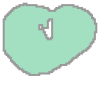

In [43]:
# Quickly plot geometry of nucleus 29481
sdata.shapes["nucleus_shapes_global"].geometry[29481]

In [44]:
# Convert shapes layer back to labels layer
se = hp.im.get_dataarray(sdata, layer="nucleus_labels_global")

sdata = hp.im.rasterize(
    sdata,
    shapes_layer="nucleus_shapes_global",
    output_layer="nucleus_labels_global_copy",
    out_shape=se.shape,
    chunks=5000,
    overwrite=True,
)

2026-03-10 20:15:15.496 | INFO     | harpy.image._manager:add_layer:47 - Writing results to layer 'nucleus_labels_global_copy'
no parent found for <ome_zarr.reader.Label object at 0x148873410>: None


<b>Excercise</b>:

- Are the labels layers `nucleus_labels_global` and `nucleus_labels_global_copy` equal? Do you expect them to be equal?

<details>
<summary>Click to reveal the solution</summary>

```python
se_1 = hp.im.get_dataarray(sdata, layer="nucleus_labels_global")
se_2 = hp.im.get_dataarray(sdata, layer="nucleus_labels_global_copy")

pixels_not_equal = (~ np.equal(se_2.data.compute(), se_1.data.compute())).sum() 

print(f"After roundtrip vectorization and rasterization, {pixels_not_equal} pixels are not equal.")

print("Number of cells in nucleus_labels_global:", len(da.unique(se_1.data).compute()))
print("Number of cells in nucleus_labels_global_copy:", len(da.unique(se_2.data).compute()))


<b>Excercise</b>:
- Remove the `nucleus_labels_global_copy` layer.

<details>
<summary>Click to reveal the solution</summary>

```python
del sdata.labels["nucleus_labels_global_copy"]
sdata.delete_element_from_disk("nucleus_labels_global_copy")

#### 3.2.4 Points
Points are DaskDataFrame object (see https://docs.dask.org/en/stable/dataframe.html). Points represent the spatial location of a feature. In our case this will almost always be a gene.

In [47]:
# Inspect points layer
sdata.points["transcripts_global"]

,x,y,gene
npartitions=1,,,
,float64,float64,category[unknown]
,...,...,...


In [48]:
# Compute points layer as pandas dataframe
sdata.points["transcripts_global"].compute().head()  # This is a pandas.DataFrame

,x,y,gene
0,18908.382353,27736.764706,AAMP
0,18180.441176,27247.500000,A2ML1
0,13668.970588,27754.044118,A2ML1
0,15351.176471,27958.235294,AAMP
0,17088.161765,27187.058824,AAMP


<b>Excercise</b>:
- Use the points layer `transcripts_global` to determine how many unique genes were measured.

<details>
<summary>Click to reveal the solution</summary>

```python
sdata.points["transcripts_global"]["gene"].nunique().compute()

#### 3.2.5 Tables
Tables are [AnnData](https://anndata.readthedocs.io/en/latest/) objects. An `AnnData` object (`adata`) contains following attributes:

- `adata.X`: Main data matrix (observations x features). Observations are generally cells, while features (or variables) are generally genes.
- `adata.obs`: Metadata for each observation (e.g. QC-metrics, cell types, morphological characteristics).
- `adata.var`: Metadata for each feature (e.g. QC-metrics, gene ontology).
- `adata.uns`: Unstructured information (e.g. color schemes, settings).
- `adata.obsm`: Embeddings or reduced dimensions (e.g., PCA or UMAP coordinates, spatial coordinates).

In [49]:
# Inspect tables layer
sdata.tables["table_global"]

AnnData object with n_obs × n_vars = 34621 × 5101
    obs: 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'fov_labels', 'z_level', 'cell_ID'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

`adata.X`

- Data type is a sparse or dense NumPy array or SciPy sparse matrix.
- This is the core data matrix of the AnnData object, typically an m×n matrix, where m is the number of observations (cells), and n is the number of variables (genes).
- Stores the primary quantitative data for each cell/gene pair, such as raw counts, normalized expression values, or transformations of the raw quantifications.

In [50]:
# Inspect count matrix
sdata.tables["table_global"].X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 7604289 stored elements and shape (34621, 5101)>

In [53]:
# Get shape of data matrix
sdata.tables["table_global"].X.shape

(34621, 5101)

In [54]:
# Get matrix as dataframe
sdata.tables["table_global"].to_df().head()  # Not recommended for large datasets

,A2ML1,AAMP,AAR2,AARSD1,ABAT,ABCA1,ABCA10,ABCA3,ABCA4,ABCA7,...,ZPR1,ZSCAN1,ZSCAN12,ZSCAN16,ZSCAN20,ZSCAN26,ZSWIM6,ZUP1,ZYG11B,ZYX
cell_id,,,,,,,,,,,,,,,,,,,,,
27401,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
27402,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
27403,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
27404,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
27405,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


`adata.obs`

- Data type is a `pandas.DataFrame`.
- Each row corresponds to an observation in adata.X.
- Each colum corresponds to metadata about each observation: QC-metrics, cell types, clustering IDs, sample IDs, morphological features...

In [55]:
sdata.tables["table_global"].obs.head()

,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,nucleus_count,segmentation_method,fov_labels,z_level,cell_ID
cell_id,,,,,,,,,,,,,,
27401,1267,0,0,0,0,116,1383,162.427037,110.723129,1.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_labels_global,0.0,27401
27402,362,0,0,0,0,7,369,37.524845,NaN,0.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_labels_global,0.0,27402
27403,340,0,0,0,0,17,357,43.620939,34.544533,1.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_labels_global,0.0,27403
27404,827,0,0,0,0,72,899,110.497348,90.177035,1.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_labels_global,0.0,27404
27405,864,0,0,0,0,112,976,124.947348,80.378128,1.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_labels_global,0.0,27405


In [56]:
# Inspect number of cells per segmentation method
sdata.tables["table_global"].obs["segmentation_method"].value_counts()

segmentation_method
Segmented by interior stain (18S)                       21569
Segmented by boundary stain (ATP1A1+CD45+E-Cadherin)    11126
Segmented by nucleus expansion of 5.0µm                  1926
Name: count, dtype: int64

In [57]:
# Inspect number of nuclei per cell
sdata.tables["table_global"].obs["nucleus_count"].value_counts()

nucleus_count
1.0    32981
2.0     1022
0.0      507
3.0       98
4.0       11
5.0        2
Name: count, dtype: int64

<Axes: >

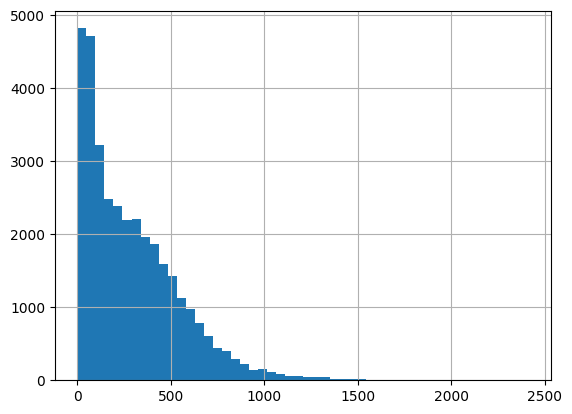

In [58]:
# Quick histogram of number of transcripts per cell
sdata.tables["table_global"].obs["transcript_counts"].hist(bins=50)

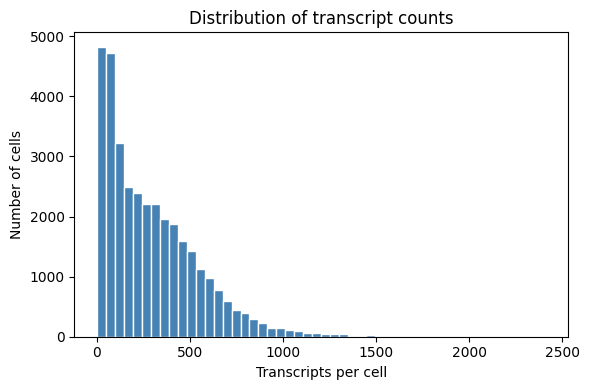

In [59]:
# Prettier histogram of number of transcripts per cell using matplotlib
ax = (
    sdata.tables["table_global"]
    .obs["transcript_counts"]
    .plot.hist(bins=50, figsize=(6, 4), edgecolor="white", color="steelblue")
)

ax.set_xlabel("Transcripts per cell")
ax.set_ylabel("Number of cells")
ax.set_title("Distribution of transcript counts")
plt.tight_layout()


`adata.var`

- Data type is a `pandas.DataFrame`.
- Each row corresponds to a feature in adata.X.
- Each colum corresponds to metadata about each feature: QC-metrics, gene ontology...

In [60]:
sdata.tables["table_global"].var.head()

,gene_ids,feature_types,genome
A2ML1,ENSG00000166535,Gene Expression,Unknown
AAMP,ENSG00000127837,Gene Expression,Unknown
AAR2,ENSG00000131043,Gene Expression,Unknown
AARSD1,ENSG00000266967,Gene Expression,Unknown
ABAT,ENSG00000183044,Gene Expression,Unknown


`adata.uns`

- `.uns` (unstructured data) is a dictionary for storing additional, often unstructured, information relevant to the dataset.
- Data type is a dictionary where you can store various data types, such as strings, arrays, or even nested dictionaries.
- Typically used for storing global dataset information, annotations, and visualization settings, like color palettes for clusters or parameter settings for computational methods

In [61]:
sdata.tables["table_global"].uns

{'spatialdata_attrs': {'region': ['cell_labels_global'],
  'region_key': 'fov_labels',
  'instance_key': 'cell_ID'}}

`adata.obsm`

- `.obsm` is a mapping of additional multi-dimensional arrays associated with each observation.
- Data type is a dictionary-like structure where each entry is typically a matrix or array of coordinates.
- Stores embeddings, dimensional reductions, spatial coordinates, or other coordinate-based data associated with observations.

In [62]:
sdata.tables["table_global"].obsm

AxisArrays with keys: spatial

In [63]:
sdata.tables["table_global"].obsm["spatial"][
    :5
]  # Contains centroid coordinates of cells (in pixels!)

array([[10028.73046875, 18583.42026654],
       [ 9990.6238511 , 18550.43428309],
       [10035.76516544, 18544.91498162],
       [10003.05721507, 18513.50988051],
       [10010.23782169, 18468.30882353]])

`Region key` and `Instance key`
According to spatialdata, a table layer can be annotated by a spatial element (`labels`, `shapes`, `points`), but tables generated by `Harpy` will be annotated by a `labels` layer.

In [64]:
from spatialdata.models import TableModel

sdata.tables["table_global"].uns[TableModel.ATTRS_KEY]

{'region': ['cell_labels_global'],
 'region_key': 'fov_labels',
 'instance_key': 'cell_ID'}

In [65]:
from harpy.utils._keys import _INSTANCE_KEY, _REGION_KEY

print(
    "Instance key column:", _INSTANCE_KEY
)  # Column in .obs that will be used for cell_ID
print(
    "Region key column:", _REGION_KEY
)  # Column in .obs that will be used for linking AnnData object to spatial element (a labels layer, e.g. a segmentation mask).

Instance key column: cell_ID
Region key column: fov_labels


In [66]:
# Inspect instance and region keys in obs
sdata.tables["table_global"].obs.head()

,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,nucleus_count,segmentation_method,fov_labels,z_level,cell_ID
cell_id,,,,,,,,,,,,,,
27401,1267,0,0,0,0,116,1383,162.427037,110.723129,1.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_labels_global,0.0,27401
27402,362,0,0,0,0,7,369,37.524845,NaN,0.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_labels_global,0.0,27402
27403,340,0,0,0,0,17,357,43.620939,34.544533,1.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_labels_global,0.0,27403
27404,827,0,0,0,0,72,899,110.497348,90.177035,1.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_labels_global,0.0,27404
27405,864,0,0,0,0,112,976,124.947348,80.378128,1.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_labels_global,0.0,27405


In [67]:
# Inspect instance key values in obs
sdata.tables["table_global"].obs[_INSTANCE_KEY].values[:5]

array([27401, 27402, 27403, 27404, 27405])

In [68]:
# Shapes index correspond to cell_ID values
sdata.shapes["nucleus_shapes_global"].index[:5]

Index([29481, 29482, 29483, 29484, 29497], dtype='uint32', name='cell_ID')

In [69]:
# Segmentation labels correspond to cell_ID values
se = hp.im.get_dataarray(sdata, layer="nucleus_labels_global")
da.unique(se.data).compute()[
    :6
]  # Note that there is an value of 0, but this is reserved for the background and is not found in the table layer or shapes layer.

array([    0, 29481, 29482, 29483, 29484, 29497], dtype=uint32)

<b>Excercise</b>:
- Explore the cell_area column in the table layer. What is the average? What does the distribution look like?

<details>
<summary>Click to reveal the solution</summary>

```python
sdata.tables["table_global"].obs['cell_area'].describe()

ax = sdata.tables["table_global"].obs['cell_area'].plot.hist(
    bins=50,
    figsize=(6,4),
    edgecolor='white',
    color='steelblue'
)

ax.set_xlabel("Cell area")
ax.set_ylabel("Number of cells")
ax.set_title("Distribution of cell areas")
plt.tight_layout()

### 3.3 Plotting
Plotting of the different spatial elements of a SpatialData object can be done using [spatialdata-plot](https://spatialdata.scverse.org/projects/plot/en/stable/plotting.html). However, in Harpy, we added a convenient wrapper around spatialdata-plot to allow easier cropping during plotting, consistent colors and a simpler API.

#### 3.3.1 spatialdata-plot

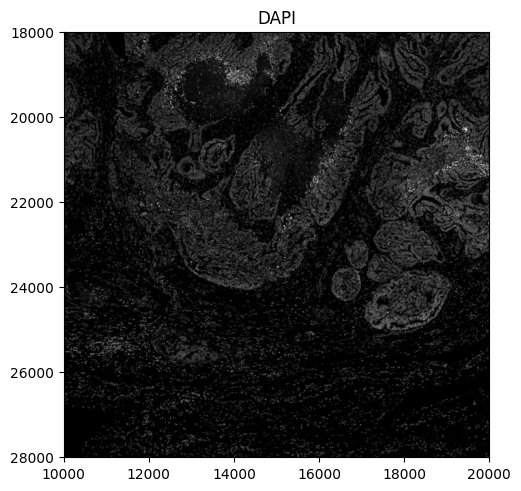

In [71]:
# We can plot the DAPI image using spatialdata-plot
sdata.pl.render_images(
    element="morphology_focus_global",
    channel="DAPI",
    cmap="gray",
).pl.show(
    coordinate_systems="global",
    title="DAPI",
    colorbar=False,
)

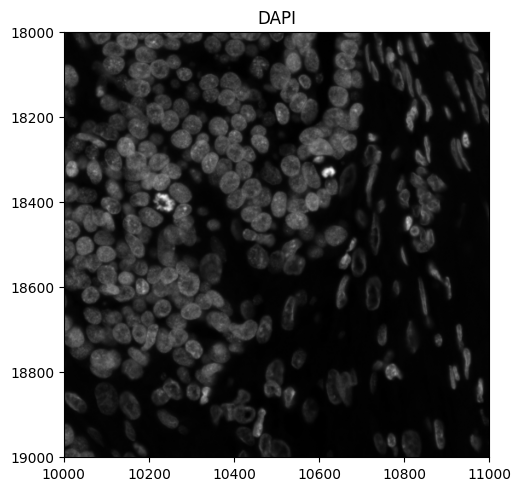

In [72]:
# To plot a crop of the image, we need to first do a bounding box query
min_x = 10000
max_x = 11000
min_y = 18000
max_y = 19000

sdata_crop = sdata.query.bounding_box(
    min_coordinate=[min_x, min_y],
    max_coordinate=[max_x, max_y],
    axes=("x", "y"),
    target_coordinate_system="global",
)

# We can plot the DAPI image using spatialdata-plot
sdata_crop.pl.render_images(
    element="morphology_focus_global",
    channel="DAPI",
    cmap="gray",
).pl.show(
    coordinate_systems="global",
    title="DAPI",
    colorbar=False,
)

INFO     Converted 9 Polygon(s) with holes to MultiPolygon(s) for correct rendering.                               


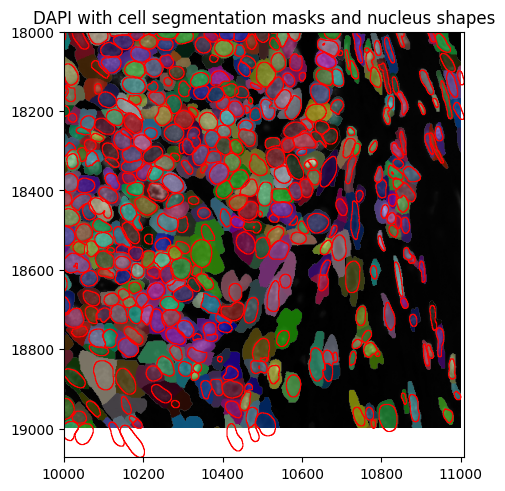

In [73]:
# To create more complex plots, we can chain the render functions
sdata_crop.pl.render_images(
    element="morphology_focus_global",
    channel="DAPI",
    cmap="gray",
).pl.render_labels(
    element="cell_labels_global", fill_alpha=0.3, contour_px=5, outline_alpha=0
).pl.render_shapes(
    element="nucleus_shapes_global",
    fill_alpha=0,
    outline_width=0.8,
    outline_alpha=1,
    outline_color="red",
).pl.show(
    coordinate_systems="global",
    title="DAPI with cell segmentation masks and nucleus shapes",
    colorbar=False,
)


WARNING  Converting copy of 'segmentation_method' column to categorical dtype for categorical plotting. Consider   
         converting before plotting.                                                                               
INFO     Converted 9 Polygon(s) with holes to MultiPolygon(s) for correct rendering.                               


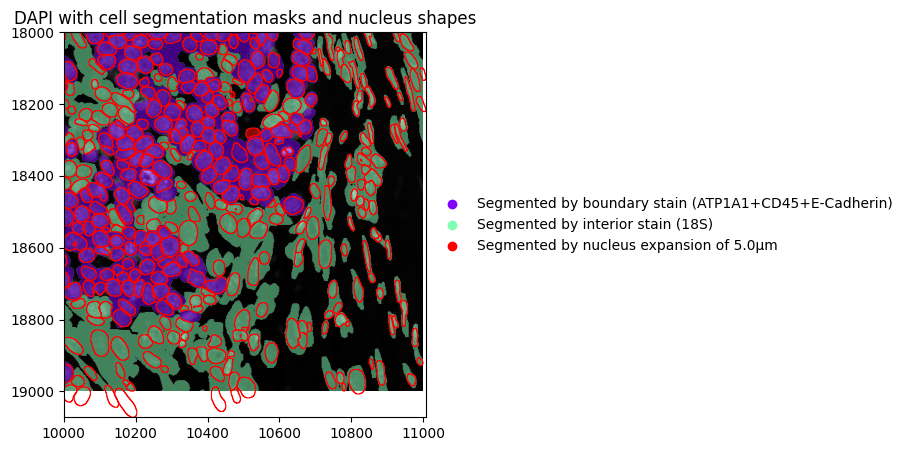

In [74]:
# To can also plot the genes and obs columns from the table layer
sdata_crop.pl.render_images(
    element="morphology_focus_global",
    channel="DAPI",
    cmap="gray",
).pl.render_labels(
    element="cell_labels_global",
    fill_alpha=0.3,
    contour_px=5,
    outline_alpha=0,
    cmap="rainbow",
    color="segmentation_method",
    table_name="table_global",
).pl.render_shapes(
    element="nucleus_shapes_global",
    fill_alpha=0,
    outline_width=0.8,
    outline_alpha=1,
    outline_color="red",
).pl.show(
    coordinate_systems="global",
    title="DAPI with cell segmentation masks and nucleus shapes",
    colorbar=False,
    legend_fontsize=10,
    legend_fontweight="bold",
    legend_loc="right margin",
    figsize=(5, 5),
)

WARNING  Converting copy of 'segmentation_method' column to categorical dtype for categorical plotting. Consider   
         converting before plotting.                                                                               
INFO     Converted 9 Polygon(s) with holes to MultiPolygon(s) for correct rendering.                               
Plot saved at: /Users/arne.defauw/VIB/DATA/test_data/test_plot.png


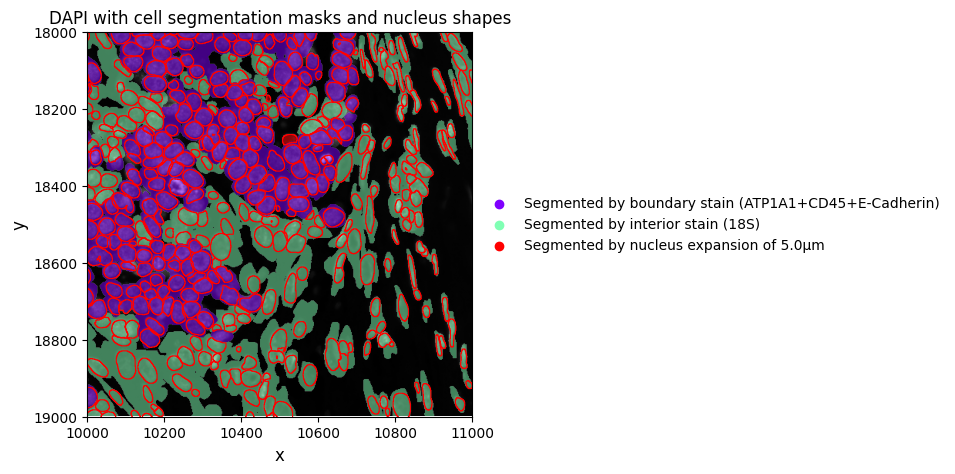

In [75]:
# However, we might want to clean up the plots a bit more, leading to large chunks of code.
min_x = 10000
max_x = 11000
min_y = 18000
max_y = 19000

sdata_crop = sdata.query.bounding_box(
    min_coordinate=[min_x, min_y],
    max_coordinate=[max_x, max_y],
    axes=("x", "y"),
    target_coordinate_system="global",
)

fig, ax = plt.subplots(
    figsize=(5, 5)
)  # We create a figure and axis object to have more control over the plot aesthetics.
# fig (Figure) refers to the entire canvas. It can contain one or many Axes (subplots). It controls global properties such as overall size, layout, background, and saving the final image.
# ax (Axes) corresponds to the actual plotting area inside the figure. It contains the x‑axis, y‑axis, titles, points, etc. Each subplot is one Axes object.

title = "DAPI with cell segmentation masks and nucleus shapes"

sdata_crop.pl.render_images(
    element="morphology_focus_global",
    channel="DAPI",
    cmap="gray",
).pl.render_labels(
    element="cell_labels_global",
    fill_alpha=0.3,
    contour_px=1,
    outline_alpha=0,
    cmap="rainbow",
    color="segmentation_method",
    table_name="table_global",
).pl.render_shapes(
    element="nucleus_shapes_global",
    fill_alpha=0,
    outline_width=0.8,
    outline_alpha=1,
    outline_color="red",
).pl.show(
    coordinate_systems="global",
    title=title,
    colorbar=False,
    figsize=(5, 5),
    ax=ax,
    legend_fontsize=10,
    legend_fontweight="bold",
    legend_loc="right margin",
    na_in_legend=True,
)

ax.set_title(title, fontsize=12)  # This allows us to set the title font size
ax.set_xlabel("x", fontsize=12)  # This adds a label to x-axis and sets the font size
ax.set_ylabel("y", fontsize=12)  # This adds a label to y-axis and sets the font size
ax.tick_params(
    axis="both", which="both", labelsize=10
)  # This allows us to set the tick label size

ax.set_xlim(
    min_x, max_x
)  # This limits the axes to the same bounding box as the query, which avoids shapes from a shapes layer breaking the frame.
ax.set_ylim(min_y, max_y)
ax.invert_yaxis()  # Setting the xlim and ylim inverts the axes and this line inverts the yaxis back to the correct orientation for microscopy images.

save_path = os.path.join(output_path, "test_plot.png")
fig.savefig(
    save_path,
    bbox_inches="tight",
    pad_inches=0.05,
    facecolor="white",
    transparent=False,
)  # This saves the plot to disk

# plt.close(fig) # This closes the figure so it is not displayed in the notebook.

print("Plot saved at:", save_path, flush=True)

#### 3.3.2 Harpy
Harpy has 2 main plotting functions to plot the contents of a SpatialData object: hp.pl.plot_sdata() and hp.pl.plot_sdata_gene(). Note that there are also other plotting functions for more specific use-cases, but we will not look into those here.

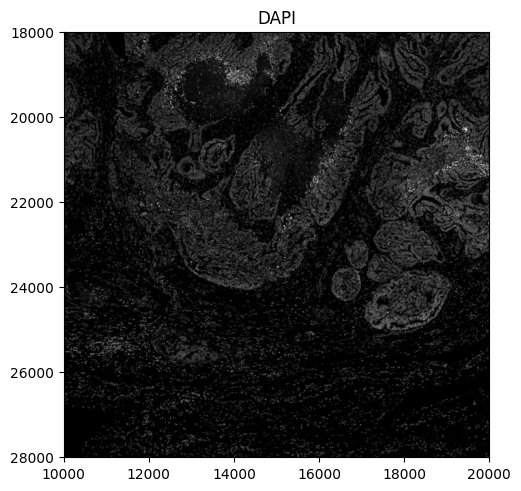

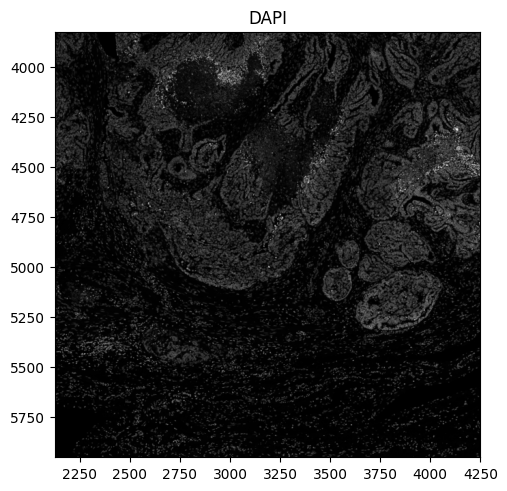

In [76]:
# Plot DAPI image using hp.pl.plot_sdata()
ax = hp.pl.plot_sdata(
    sdata,
    img_layer="morphology_focus_global",
    channel="DAPI",
    crd=None,  # Define crop to plot (xmin, xmax, ymin, ymax)
    to_coordinate_system="global",
    render_images_kwargs={
        "cmap": "grey"
    },  # keyword arguments passed on to spatialdata-plot's .pl.render_images()
    show_kwargs={
        "title": "DAPI",
        "colorbar": False,
    },  # keyword arguments passed on to spatialdata-plot's .pl.show()
)

# or in microns:

ax = hp.pl.plot_sdata(
    sdata,
    img_layer="morphology_focus_global",
    channel="DAPI",
    crd=None,  # Define crop to plot (xmin, xmax, ymin, ymax)
    to_coordinate_system="global_micron",
    render_images_kwargs={
        "cmap": "grey"
    },  # keyword arguments passed on to spatialdata-plot's .pl.render_images()
    show_kwargs={
        "title": "DAPI",
        "colorbar": False,
    },  # keyword arguments passed on to spatialdata-plot's .pl.show()
)

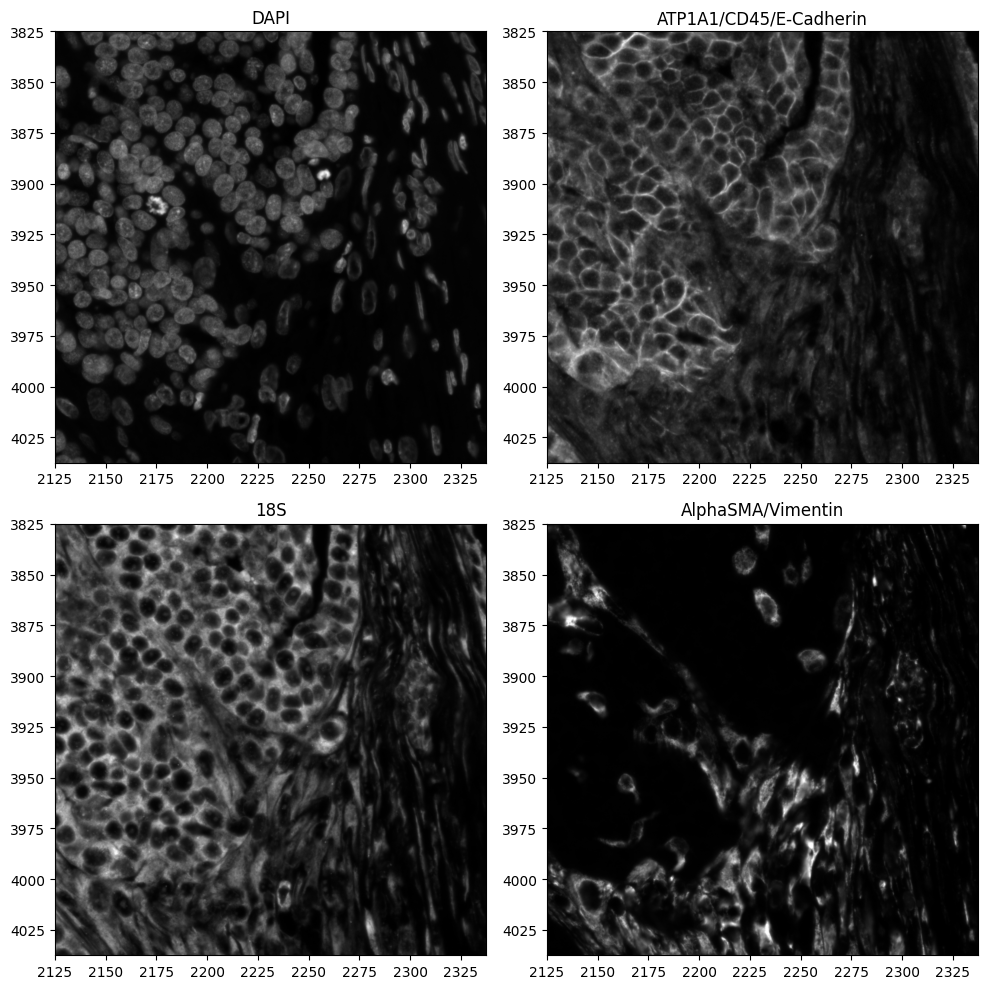

In [77]:
# Plot all channels for a crop of the image
pixel_size = 0.2125  # We need to specify the coordinates in micron if we want to use the micron coordinate system

min_x = 10000 * pixel_size
max_x = 11000 * pixel_size
min_y = 18000 * pixel_size
max_y = 19000 * pixel_size

channels = ["DAPI", "ATP1A1/CD45/E-Cadherin", "18S", "AlphaSMA/Vimentin"]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for ax, channel in zip(axes.ravel(), channels):
    ax = hp.pl.plot_sdata(
        sdata,
        img_layer="morphology_focus_global",
        channel=channel,
        crd=(
            min_x,
            max_x,
            min_y,
            max_y,
        ),  # Define crop to plot (xmin, xmax, ymin, ymax)
        to_coordinate_system="global_micron",  # We are plotting in the micron coordinates
        render_images_kwargs={"cmap": "grey"},
        show_kwargs={"title": channel, "colorbar": False},
        ax=ax,
    )

plt.tight_layout()
plt.show()

<Axes: title={'center': 'Cell segmentation'}>

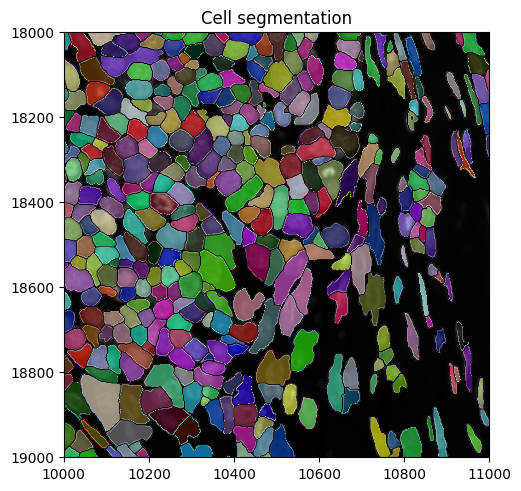

In [78]:
# Plot cell segmentation mask
hp.pl.plot_sdata(
    sdata,
    img_layer="morphology_focus_global",
    channel="DAPI",
    labels_layer="cell_labels_global",
    crd=(10000, 11000, 18000, 19000),
    render_images_kwargs={"cmap": "grey"},
    render_labels_kwargs={"fill_alpha": 0.4, "contour_px": 3, "outline_alpha": 1},
    show_kwargs={"title": "Cell segmentation", "colorbar": False},
)

2026-03-10 20:17:44.477 | INFO     | harpy.plot._plot_sdata:plot_sdata_genes:542 - Plotting column gene of 'sdata.points[transcripts_global]' as categorical.


INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


<Axes: title={'center': 'Transcripts'}>

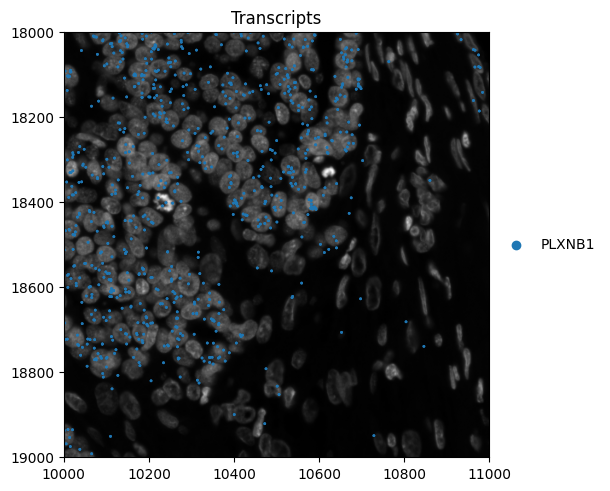

In [79]:
# Plot transcripts for a specific gene
hp.pl.plot_sdata_genes(
    sdata,
    img_layer="morphology_focus_global",
    channel="DAPI",
    points_layer="transcripts_global",
    crd=(10000, 11000, 18000, 19000),
    color="cornflowerblue",
    genes=["PLXNB1"],  # List of genes to plot (if None, all genes will be plotted)
    frac=1,  # We can also randomly subsampling transcripts to speed up plotting
    size=1,
    render_images_kwargs={"cmap": "grey"},
    show_kwargs={"title": "Transcripts", "colorbar": False},
    to_coordinate_system="global",
)

## 4. BigWarp registration

### 4.1 Registration using BigWarp
Since this dataset contains an H&E that was acquired after the Xenium run, we will register it to the fluorescent images and transcript coordinate space using the [BigWarp-plugin](https://imagej.net/plugins/bigwarp) in [FIJI](https://fiji.sc/) and add it to the SpatialData object.

For this notebook, we will follow the instructions as outlined in this [documentation](https://github.com/vibspatial/bigwarp). Specifically, we will download an installation of FIJI and BigWarp using the link in the documentation, create a BigWarp dataset, place landmarks on the DAPI (fixed image) and H&E images (moving image), and then export a warped version of the H&E image using a Thin-Plate Spline transformation. Note that we will not create the conda environment as described in the documentation since we will export to TIFF (and not to Zarr).

### 4.2 Adding the warped H&E image to the SpatialData object

In [ ]:
# Specify the path to the warped H&E image and read in the image
from dask_image.imread import imread

path_warped_image = registry.fetch(
    "transcriptomics/xenium/Xenium_human_ovarian_cancer/training_march_2026/HE_warped_TPS.tiff"
)  # This sets the path to the BigWarp H&E from the registry. You can also supply your own path.
img = imread(path_warped_image)
img

In [ ]:
# Squeeze and transpose image for hp.im.add_image_layer()
img = img.squeeze(0).transpose(
    (2, 0, 1)
)  # Squeeze unused dimension, and transpose to make it (c,y,x)
img

In [ ]:
# Rechunk image
img = img.rechunk(1024)
img

In [ ]:
sdata = hp.im.add_image_layer(
    sdata,  # The SpatialData object to which the new image layer will be added.
    arr=img,  # The array containing the image data to be added.
    dims=("c", "y", "x"),  # A tuple specifying the dimensions of the image data
    output_layer="he_image_bigwarp",  # The name of the output layer where the image data will be stored.
    transformations={
        "global": Identity()
    },  # NOTE: we only add it to the pixel coordinate system "global" for simplicity
    overwrite=True,
    scale_factors=(2, 2, 2),  # save as multiscale
)

In [ ]:
# Plot warped H&E
sdata.pl.render_images(
    element="he_image_bigwarp"
).pl.show()  # spatialData-plot knows to plot an H&E as an RGB image.

In [ ]:
# Let's check whether the H&E is registered correctly to other spatial elements
min_x = 10000
max_x = 11000
min_y = 18000
max_y = 19000

sdata_crop = sdata.query.bounding_box(
    min_coordinate=[min_x, min_y],
    max_coordinate=[max_x, max_y],
    axes=("x", "y"),
    target_coordinate_system="global",
)

fig, ax = plt.subplots(figsize=(5, 5))

sdata_crop.pl.render_images(
    element="he_image_bigwarp",
).pl.render_shapes(
    element="nucleus_shapes_global",
    fill_alpha=0,
    outline_width=0.6,
    outline_alpha=1,
    outline_color="lightblue",
).pl.show(
    coordinate_systems="global",
    colorbar=False,
    title="BigWarp H&E with nucleus shapes",
    ax=ax,
)

ax.set_xlabel("x")
ax.set_ylabel("y")

ax.set_xlim(min_x, max_x)
ax.set_ylim(min_y, max_y)
ax.invert_yaxis()

### 4.3 Adding the original H&E image with an affine transformation
Alternatively, we can use the affine transformation matrix supplied by 10X Genomics and add the original H&E with the affine transformation specified in the SpatialData object. This workflow can be useful if you want to use the affine transformation matrix from BigWarp or some other registration method. Note that nonlinear transformations (e.g. TPS from BigWarp) are not supported by SpatialData.

In [ ]:
# Specify the path to the original H&E image

from harpy.datasets import get_registry
from spatialdata.transformations import Affine

path_he_image = registry.fetch(
    "transcriptomics/xenium/Xenium_human_ovarian_cancer/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_he_image.ome.tif"
)
path_transformation = registry.fetch(
    "transcriptomics/xenium/Xenium_human_ovarian_cancer/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_he_imagealignment.csv"
)

# Read in the transformation parameters from the CSV file
transformations_df = pd.read_csv(
    path_transformation, header=None
)  # We read in the affine transformation supplied by 10X Genomics as a pandas dataframe.
A = transformations_df.values  # Convert to a numpy array
affine_transform = Affine(A, input_axes=("x", "y"), output_axes=("x", "y"))

# The original H&E image is read using dask image
img = imread(path_he_image)
img = img.squeeze().transpose((2, 0, 1))  # Remove unused dimensions

transformations = {
    "global": affine_transform
}  # for simplicity we do not add the micron coordinate system here

sdata = hp.im.add_image_layer(
    sdata,
    arr=img.rechunk(1024),
    dims=("c", "y", "x"),
    output_layer="he_image_original",
    chunks=1024,
    overwrite=True,
    transformations=transformations,  # We can specify the transformations to be added to the image layer here
    scale_factors=(2, 2, 2),
)

In [ ]:
# Let's check whether the H&E is registered correctly to other spatial elements
min_x = 10000
max_x = 11000
min_y = 18000
max_y = 19000

sdata_crop = sdata.query.bounding_box(
    min_coordinate=[min_x, min_y],
    max_coordinate=[max_x, max_y],
    axes=("x", "y"),
    target_coordinate_system="global",
)

fig, ax = plt.subplots(figsize=(5, 5))

sdata_crop.pl.render_images(
    element="he_image_original",
).pl.render_shapes(
    element="nucleus_shapes_global",
    fill_alpha=0,
    outline_width=0.6,
    outline_alpha=1,
    outline_color="lightblue",
).pl.show(
    coordinate_systems="global",
    colorbar=False,
    title="Original H&E (affine transformation) with nucleus shapes",
    ax=ax,
)

ax.set_xlabel("x")
ax.set_ylabel("y")

ax.set_xlim(min_x, max_x)
ax.set_ylim(min_y, max_y)
ax.invert_yaxis()

## 5. Region annotation
We will now create some region annotations on the warped H&E image. This makes sure the region annotations are in the same coordinate space as the fluorescent images and the transcripts. This is by far the easiest and most straight-forward workflow and is usually recommended. We can do this both in Napari and in Qupath.

However, in some cases, you may prefer to annotate on the original unwarped H&E and transform the region annotations according to the BigWarp tranformation. For this more complex scenario, we have created some documentation and tools, which you can find [here](https://github.com/vibspatial/bigwarp/blob/main/transform_geometries/transform_geometries.ipynb).

Note that you also have the option to annotate on the original unwarped H&E and add the region annotations to the SpatialData object with an affine transformation matrix specified (see 5.3). This, of course, requires that you know the affine transformation matrix. Since this is very similar to what was covered in 5.3, we will not cover it here again.

### 5.1 Region annotation in Napari
In napari, we will create a new shapes layer (rename the layer to 'region_annotation'), annotate a region of interest, save to sdata using Shift + E and close Napari.

For more info, see [this link](https://spatialdata.scverse.org/en/latest/tutorials/notebooks/notebooks/examples/napari_rois.html). Note that there is, currently, only support for saving rectangles, polygons and points.

In [ ]:
# Open Napari to create region annotation
Interactive(sdata)

In [ ]:
# Let's check the sdata object to see whether the layer was correctly added
sdata

In [ ]:
# We need to make sure the shapes layer is backed to zarr
from spatialdata import read_zarr

sdata.write_element(element_name="region_annotation")
sdata = read_zarr(sdata.path)
sdata

In [ ]:
# Let's plot the region annotation
sdata.pl.render_images(element="he_image_bigwarp").pl.render_shapes(
    element="region_annotation",
    color="cyan",
    fill_alpha=0.15,
    outline_alpha=1,
    outline_color="cyan",
).pl.show(
    coordinate_systems="global",
    title="Region annotation Napari",
)

In [ ]:
# We can export the annotation as a GeoJSON to, for example, read it into Xenium Explorer
sdata.shapes["region_annotation"].to_file(
    os.path.join(output_path, "region_annotation.geojson"), driver="GeoJSON"
)

<b>Excercise</b>:
- Create your own region annotation in Napari, add it to the SpatialData and plot the results.
- BONUS: Can you create an annotation in Xenium Explorer and add it to the SpatialData and plot the results.

### 5.2 Qupath region annotation
Qupath is open source software for bioimage analysis. It has some really nice tools for annotating regions of interest and artifacts in images. We will use these for our dataset and add the results to the SpatialData object.

1. If necessary, install QuPath (v.0.6.0) using this [link](https://qupath.github.io/).
2. Open Qupath and click `Create project` in the top left corner.
3. Create a new empty folder for the project and click `Select Folder`.
4. To add images, go to `Add images` and provide the path to the warped H&E image.
5. Explore the image by going to `Brightness & contrast`, select the channels you want to visualize and adjust the settings to improve the visualization.
6. Annotate a region using the annotation tools.
7. Export the region annotation. Select all artifact annotations you want to export and go to `File`, `Export objects as GeoJSON` and set to `Selected objects` and `Compression` to None. Click `OK` and pick a file name.

In [ ]:
# We will add the region annotations we already created based on the annotations supplied by 10X Genomics.
paths_to_GeoJSONs = {
    "tumor": registry.fetch(
        "transcriptomics/xenium/Xenium_human_ovarian_cancer/training_march_2026/tumor.geojson"
    ),
    "necrosis": registry.fetch(
        "transcriptomics/xenium/Xenium_human_ovarian_cancer/training_march_2026/necrosis.geojson"
    ),
    "ovary": registry.fetch(
        "transcriptomics/xenium/Xenium_human_ovarian_cancer/training_march_2026/ovary.geojson"
    ),
    "fallopian_tube": registry.fetch(
        "transcriptomics/xenium/Xenium_human_ovarian_cancer/training_march_2026/fallopian_tube.geojson"
    ),
    "smooth_muscle": registry.fetch(
        "transcriptomics/xenium/Xenium_human_ovarian_cancer/training_march_2026/smooth_muscle.geojson"
    ),
}

for name, path in paths_to_GeoJSONs.items():
    gdf_regions = gpd.read_file(path)
    sdata = hp.sh.add_shapes_layer(
        sdata, input=gdf_regions, output_layer=name, overwrite=True
    )

In [ ]:
# Let's check whether the region annotations were added correctly
sdata.pl.render_images(element="he_image_bigwarp").pl.render_shapes(
    element="tumor", color="red", fill_alpha=0.15, outline_alpha=1, outline_color="red"
).pl.render_shapes(
    element="necrosis",
    color="black",
    fill_alpha=0.15,
    outline_alpha=1,
    outline_color="black",
).pl.render_shapes(
    element="ovary",
    color="lightgreen",
    fill_alpha=0.15,
    outline_alpha=1,
    outline_color="lightgreen",
).pl.render_shapes(
    element="smooth_muscle",
    color="blue",
    fill_alpha=0.15,
    outline_alpha=1,
    outline_color="blue",
).pl.render_shapes(
    element="fallopian_tube",
    color="darkgreen",
    fill_alpha=0.15,
    outline_alpha=1,
    outline_color="darkgreen",
).pl.show(
    coordinate_systems="global",
    title="Region annotations Qupath",
)

<b>Excercise</b>:
- Create your own region annotation in Qupath and add it to the SpatialData. Plot the resulting shapes layer.

### 5.3 ADVANCED: Registering region annotations using BigWarp
Follow the steps detailed in this [documentation](https://github.com/vibspatial/bigwarp/blob/main/transform_geometries/transform_geometries.ipynb). To sucessfully run this, you need to download the `vibspatial/bigwarp` github repository, open the `transform_geometries.ipynb` notebook, adjust the paths and follow the instructions.

In this training, we will register one of the region annotations (fallopian_tube.geojson) created in Qupath on the original fluorescent images (since we already have this) and transform it in the reverse direction to coordinate space of the H&E. We can check whether we were successful by opening both the original H&E and the warped region annotation GeoJSON in Qupath.

In short, there are 4 steps we need to do:

<b>Steps</b>:
1. Convert the GeoJSON geometries of fallopian_tube.geojson into a series of coordinates using the `convert_geometries_for_bigwarp` function in the notebook.
2. Transform the exported coordinates according to the BigWarp transformation using the `warp_points_bigwarp.groovy` script in FIJI.
3. Reconstruct GeoJSON geometries from the warped coordinates using the `create_warped_geometries` function in the notebook.
4. Open the original H&E and the warped GeoJSON in Qupath to verify the registration was succesful.

<b>Important note 1 </b>: Since Qupath saves the coordinates in the GeoJSON-file in pixel coordinates, but the BigWarp landmark file that we created earlier contains the landmark coordinates in millimeter, we need to scale the landmark coordinates in the groovy script to pixels. We know that the pixel size of the fixed image (morphology_focus_0000.tiff) is 0.2125 micrometer and the pixel size of moving image (Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_he_image.ome.tif) is 0.2738 micrometer. See settings below.

<b>Important note 2 </b>: Since we are transforming from the fixed image coordinate space to the moving image coordinate space, we need to make sure `Reverse direction` is selected. See settings below.

![alt text](Screenshot.png)